# AML Legal Case Intelligence
Deep insights from the structured case analysis pipeline

In [102]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

# ── Dark theme ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0a0e1a',
    'axes.facecolor':    '#111827',
    'axes.edgecolor':    '#1e2d45',
    'axes.labelcolor':   '#94a3b8',
    'axes.titlecolor':   '#f1f5f9',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.grid':         True,
    'grid.color':        '#1e2d45',
    'grid.linewidth':    0.5,
    'text.color':        '#94a3b8',
    'xtick.color':       '#475569',
    'ytick.color':       '#475569',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'monospace',
    'figure.dpi':        130,
    'legend.facecolor':  '#111827',
    'legend.edgecolor':  '#1e2d45',
    'legend.fontsize':   9,
})

# Palette
AML_COLOURS = {
    'Confirmed Verdict':  '#ef4444',
    'Alleged/Charged':    '#f97316',
    'Precedent Only':     '#3b82f6',
    'Not AML':            '#475569',
}
VERDICT_COLOURS = {
    'Convicted':       '#ef4444',
    'Acquitted':       '#10b981',
    'Charged/Pending': '#f97316',
    'Mentioned Only':  '#475569',
    'Not Finalized':   "#494A4C",
}
# POCA (Proceeds of Crime Act) colour mapping
# The keys correspond to the relevant sections of the POCA legislation, and the values are hex colour codes for visualization purposes.
# In future, this mapping can be expanded to include more sections or adjusted based on specific visualization needs. I will refresh and refernece the poca_reference.json file to ensure accuracy and completeness of the mapping.
POCA_COLOURS = {

    # ── Part 2 — Confiscation (purple family) ─────────────────────────────────
    # Restraint orders, confiscation orders, criminal lifestyle assumptions,
    # property valuations. Purple signals the coercive/punitive regime.
    's6':     '#a855f7',   # Confiscation orders (England and Wales)
    's10':    '#c084fc',   # Assumptions (criminal lifestyle)
    's16':    '#d8b4fe',   # Statement of information
    's40(2)': '#9333ea',   # Conditions for restraint orders
    's41':    '#7c3aed',   # Restraint orders
    's80':    '#b57bee',   # Value of property obtained from conduct
    's82':    '#e9d5ff',   # Free property
    's83':    '#ddd6fe',   # Realisable property

    # ── Part 5, Chapter 1 — Civil Recovery: Introductory (blue family) ────────
    's240':   '#3b82f6',   # General purpose
    's241':   '#2563eb',   # Unlawful conduct
    's242':   '#1d4ed8',   # Property obtained through unlawful conduct

    # ── Part 5, Chapter 2 — Civil Recovery Orders (cyan/teal family) ─────────
    's240(2)':  '#06b6d4',  # General purpose (civil recovery independence)
    's241(1)':  '#0891b2',  # Unlawful conduct — domestic
    's241(2)':  '#0e7490',  # Unlawful conduct — extraterritorial
    's241(3)':  '#155e75',  # Standard of proof
    's242(2)':  '#164e63',  # Property obtained through unlawful conduct (general)
    's243':     '#22d3ee',  # Proceedings for recovery orders
    's243(1)':  '#67e8f9',  # Proceedings — England and Wales / Northern Ireland
    's245A':    '#a5f3fc',  # Property freezing orders
    's245C':    '#cffafe',  # Property freezing orders: exclusions
    's266':     '#2dd4bf',  # Recovery orders
    's266(1)':  '#14b8a6',  # Duty to make recovery order
    's272':     '#0f766e',  # Associated property: default of agreement

    # ── Part 5, Chapter 3 — Cash Recovery (sky blue family) ──────────────────
    's289(6)':  '#38bdf8',  # Definition of cash
    's294':     '#0ea5e9',  # Seizure of cash
    's295':     '#0284c7',  # Detention of seized cash
    's295(1)':  '#0369a1',  # Detention — initial 48 hours
    's295(2)':  '#075985',  # Detention — extension by court order
    's295(5)':  '#0c4a6e',  # Detention — application for release
    's295(8)':  '#7dd3fc',  # Detention — interest
    's297':     '#bae6fd',  # Release of detained cash
    's298':     '#e0f2fe',  # Forfeiture of cash
    's298(2)':  '#f0f9ff',  # Forfeiture — court order

    # ── Part 5, Chapter 4 — Civil Recovery: General (indigo family) ──────────
    's304':     '#6366f1',  # Property obtained through unlawful conduct
    's304(1)':  '#4f46e5',  # Property obtained — definition
    's305':     '#4338ca',  # Traced property
    's306':     '#3730a3',  # Mixing property
    's307':     '#312e81',  # Profits
    's308':     '#818cf8',  # General exceptions
    's314':     '#a5b4fc',  # Rules of court
    's316':     '#c7d2fe',  # General interpretation

    # ── Part 7 — Money Laundering (existing scheme, extended) ─────────────────
    's327':     '#8b5cf6',  # Concealing etc.
    's328':     '#3b82f6',  # Arrangements
    's329':     '#06b6d4',  # Acquisition, use and possession
    's329(1)':  '#0891b2',  # Acquisition — criminal property
    's329(2)':  '#155e75',  # Acquisition — exemptions
    's330':     '#10b981',  # Failure to disclose: regulated sector
    's331':     '#34d399',  # Failure to disclose: nominated officers
    's333':     '#f43f5e',  # Tipping off
    's333A':    '#e11d48',  # Tipping off: regulated sector
    's335':     '#6ee7b7',  # Appropriate consent
    's337':     '#86efac',  # Protected disclosures
    's338':     '#bbf7d0',  # Authorised disclosure
    's340':     '#94a3b8',  # Interpretation
    's340(3)':  '#64748b',  # Criminal property definition
    's340(11)': '#475569',  # Money laundering definition

    # ── Part 8 — Investigations (amber/orange family) ─────────────────────────
    's341(3A)':   '#f59e0b',  # Detained cash investigation
    's341(4)':    '#d97706',  # Money laundering investigation
    's342':       '#b45309',  # Offence of prejudicing investigation
    's345':       '#fbbf24',  # Production orders
    's346':       '#fde68a',  # Requirements for production order
    's346(2)':    '#fef3c7',  # Production order — conditions
    's346(4)':    '#fffbeb',  # Production order — value and public interest
    's352':       '#fb923c',  # Search and seizure warrants
    's352(1)':    '#f97316',  # Search warrants — power
    's352(6)(b)': '#ea580c',  # Search warrants — seize and retain
    's353':       '#fed7aa',  # Requirements where warrant applied for
    's353(5)':    '#ffedd5',  # Requirements — second conditions
    's353(8)':    '#fff7ed',  # Requirements — unreasonable refusal of entry
    's353(9)':    '#fdba74',  # Requirements — unreasonable refusal of access
    's355':       '#c2410c',  # Further provisions: warrants
    's355(1)':    '#9a3412',  # Further provisions — PACE safeguards
    's377':       '#7c2d12',  # Codes of practice
    's415':       '#fca5a1',  # Money laundering offences — interpretation

    # ── Wrong statute — warning red ───────────────────────────────────────────
    # Erroneously extracted from other Acts. Flagged red so they stand out.
    's170':     '#dc2626',  # CEMA 1979 — fraudulent evasion of duty
    's170(2)':  '#b91c1c',  # CEMA 1979 — knowingly concerned in evasion
    's78':      '#991b1b',  # PACE 1984 — exclusion of unfair evidence

    # ── Catch-alls ────────────────────────────────────────────────────────────
    'Multiple': '#f59e0b',
    'N/A':      '#475569',
}
ACCENT  = '#f59e0b'
GREEN   = '#10b981'
BLUE    = '#3b82f6'
PALETTE = ['#f59e0b','#3b82f6','#10b981','#ef4444','#8b5cf6','#f97316','#06b6d4','#a3e635']

print('Environment ready.')

Environment ready.


In [103]:
# ── Load all case JSONs from outputs ──────────────────────────────────────────
output_dir = Path('/Users/kwabs/Desktop/Python Applications/Legal AI Agent/outputs')
json_files = sorted(output_dir.rglob('*.json'))

if not json_files:
    raise FileNotFoundError('No JSON files found in outputs — run main.py first')

cases = []
errors = []
for f in json_files:
    with open(f) as fh:
        data = json.load(fh)

    # Handles both list (old batch format) vs dict (new standard format)
    if isinstance(data, list):
        for item in data:
            if isinstance(item, dict):
                if 'error' in item:
                    errors.append({'file': f.name, 'error': item['error']})
                else:
                    cases.append(item)
    elif isinstance(data, dict):
        if 'error' in data:
            errors.append({'file': f.name, 'error': data['error']})
        else:
            cases.append(data)
    else:
        errors.append({'file': f.name, 'error': f'Unexpected format: {type(data)}'})

print(f'Cases loaded:   {len(cases)}')
if errors:
    print(f'Errors skipped: {len(errors)}')
    for e in errors:
        print(f'  ✗ {e["file"]}: {e["error"][:80]}')

# ── Flatten to dataframes ──────────────────────────────────────────────────────

# Case-level
case_rows = []
for c in cases:
    # Safely extract the POCA titles from the new enriched dictionary
    enriched_poca = c.get('poca_sections_enriched', {})
    poca_titles = [info.get('title', '') for info in enriched_poca.values() if info.get('title')]
    # Sections fetched via the ungrounded older pipeline can carry low confidence —
    # flag them here so they're filterable across the whole batch, not just visible
    # one-by-one in Streamlit
    poca_low_confidence = [s for s, info in enriched_poca.items() if info.get('confidence', '').lower() == 'low']
    # Pairs each low-confidence section with the model's own stated reason —
    # for audit: why it flagged itself uncertain, not just that it did
    poca_confidence_reasoning = '; '.join(
        f"{s}: {info.get('confidence_reasoning', 'no reasoning given')}"
        for s, info in enriched_poca.items() if info.get('confidence', '').lower() == 'low'
    )
    
    case_rows.append({
        'case_reference':       c.get('case_reference'),
        'case_name':            c.get('case_name'),
        'court':                c.get('court'),
        'jurisdiction':         c.get('jurisdiction'),
        'case_date':            c.get('case_date'),
        'case_summary':         c.get('case_summary'), # NEW FIELD
        'aml_status':           c.get('aml_status'),
        'aml_status_reasoning': c.get('aml_status_reasoning'),
        'poca_sections':        ', '.join(c.get('poca_sections', [])),
        'poca_titles':          ', '.join(poca_titles), # NEW FIELD
        'poca_low_confidence':  ', '.join(poca_low_confidence), # NEW FIELD — flags unverified POCA reference data
        'poca_confidence_reasoning': poca_confidence_reasoning, # NEW FIELD — why each flagged section was uncertain
        'poca_analysis':        c.get('poca_analysis'),
        'precedent_value':      c.get('precedent_value'),
        'key_findings':         c.get('key_findings', []),
        'defendant_count':      c.get('defendant_count', 0),
        'source_file':          c.get('source_file'),
    })
df_cases = pd.DataFrame(case_rows)

# Defendant-level
def_rows = []
for c in cases:
    for d in c.get('defendants', []):
        def_rows.append({
            'case_reference':         c.get('case_reference'),
            'aml_status':             c.get('aml_status'),
            'name':                   d.get('name'),
            'role':                   d.get('role'),
            'verdict':                d.get('verdict'),
            'verdict_reasoning':      d.get('verdict_reasoning'),
            'poca_section':           d.get('poca_section'),
            'poca_section_reasoning': d.get('poca_section_reasoning'),
            'key_facts':              d.get('key_facts', []),
            'sic_count':              len(d.get('sic_codes', [])),
            'sic_overall_reasoning':  d.get('sic_overall_reasoning'), # NEW FIELD
        })
df_defs = pd.DataFrame(def_rows)

# SIC-level
sic_rows = []
for c in cases:
    for d in c.get('defendants', []):
        for sic in d.get('sic_codes', []):
            raw_conf = sic.get('confidence', 0)
            # Handle both '85%' and 85
            conf_val = int(str(raw_conf).replace('%','')) if raw_conf else 0
            sic_rows.append({
                'case_reference': c.get('case_reference'),
                'aml_status':     c.get('aml_status'),
                'defendant':      d.get('name'),
                'verdict':        d.get('verdict'),
                'poca_section':   d.get('poca_section'),
                'sic_code':       sic.get('code'),
                'sic_desc':       sic.get('description'),
                'confidence':     conf_val,
                'reasoning':      sic.get('reasoning'),
            })
df_sic = pd.DataFrame(sic_rows)

print(f'Defendants:     {len(df_defs)}')
print(f'SIC entries:    {len(df_sic)}')
print(f'Unique courts:  {df_cases["court"].nunique()}')

low_conf_cases = df_cases[df_cases['poca_low_confidence'] != '']
if len(low_conf_cases):
    print(f'\n⚠ {len(low_conf_cases)} case(s) cite low-confidence POCA sections — verify before relying on these:')
    for _, row in low_conf_cases.iterrows():
        print(f"  {row['case_reference']}: {row['poca_low_confidence']}")
        if row['poca_confidence_reasoning']:
            print(f"      → {row['poca_confidence_reasoning']}")

Cases loaded:   100
Defendants:     742
SIC entries:    1171
Unique courts:  36

⚠ 2 case(s) cite low-confidence POCA sections — verify before relying on these:
  [2014] EWHC 840 (Admin): s353(5), s353(8), s353(9)
      → s353(5): While the judgment snippet confirms that s353 contains the requirements for warrants (including a first and second set of conditions), the exact text and numbering of subsection (5) within the overall structure of s353 are reconstructed from general memory of Part 8 POCA rather than verbatim source text.; s353(8): No direct text is provided in the judgment snippet for s353(8). While it is known to be part of the 'second set of conditions' under s353, the exact assignment of subsection (8) to 'unreasonable refusal of entry' (as opposed to refusal of access to material or warrant production) is reconstructed from memory and may be transposed with subsections (7) or (9).; s353(9): No direct text is provided in the judgment snippet for s353(9). While it is known 

In [104]:
from IPython.display import display, HTML

# ── Industry Verdict Distribution Matrix ───────────────────────────────────────
# Cross-tabulates SIC codes against defendant verdict outcomes — the primary
# tool for identifying which industry sectors correlate with AML convictions.

if df_sic.empty:
    print("⚠  No SIC data loaded. Run the data-loading cell first.")
else:
    # Build cross-tab: rows = SIC code + description, cols = verdict outcomes
    sic_verdict_matrix = pd.crosstab(
        index=[df_sic['sic_code'], df_sic['sic_desc']],
        columns=df_sic['verdict'],
        margins=True,
        margins_name="Total"
    ).sort_values('Total', ascending=False)

    total_rows   = len(sic_verdict_matrix) - 1  # exclude the margins Total row
    display_rows = min(25, total_rows)

    # ── Palette (matches notebook dark theme) ─────────────────────────────────
    BG_DEEP    = '#020617'
    BG_CARD    = '#0a0e1a'
    BORDER     = '#1e2d45'
    ACCENT     = '#3b82f6'
    TEXT_HEAD  = '#e2e8f0'
    TEXT_MUTED = '#64748b'
    RED        = '#ef4444'

    # ── Determine which columns are verdict outcome cols (not Total) ───────────
    verdict_cols = [c for c in sic_verdict_matrix.columns if c != 'Total']

    # Colour verdict columns independently so each column's gradient is
    # self-normalised — avoids 'Convicted' (usually sparse) washing out
    # completely against 'Total' (always large).
    styled = (
        sic_verdict_matrix.head(display_rows).style
        .background_gradient(cmap='YlOrRd', subset=['Total'],    vmin=0)
        .background_gradient(cmap='Blues',  subset=verdict_cols, vmin=0)
        .format(precision=0)
        .set_table_styles([
            # ── Header row ────────────────────────────────────────────────────
            {'selector': 'thead th', 'props': [
                ('background-color', BORDER),
                ('color', TEXT_HEAD),
                ('font-family', 'ui-monospace, monospace'),
                ('font-size', '11px'),
                ('font-weight', '600'),
                ('text-align', 'center'),
                ('padding', '8px 12px'),
                ('border-bottom', f'1px solid {ACCENT}'),
                ('position', 'sticky'),
                ('top', '0'),
                ('z-index', '2'),
            ]},
            # ── Index (SIC code + desc) ───────────────────────────────────────
            {'selector': 'tbody th', 'props': [
                ('background-color', BG_CARD),
                ('color', TEXT_MUTED),
                ('font-family', 'ui-monospace, monospace'),
                ('font-size', '10px'),
                ('text-align', 'left'),
                ('padding', '6px 12px'),
                ('border-right', f'1px solid {BORDER}'),
                ('white-space', 'nowrap'),
            ]},
            # ── Data cells ────────────────────────────────────────────────────
            {'selector': 'td', 'props': [
                ('font-family', 'ui-monospace, monospace'),
                ('font-size', '11px'),
                ('text-align', 'center'),
                ('padding', '5px 10px'),
                ('border-bottom', f'1px solid {BG_DEEP}'),
            ]},
            # ── Alternating row stripe ─────────────────────────────────────────
            {'selector': 'tbody tr:nth-child(even)', 'props': [
                ('background-color', '#080d17'),
            ]},
            {'selector': 'tbody tr:hover', 'props': [
                ('background-color', '#0f1929'),
            ]},
            # ── Full table ────────────────────────────────────────────────────
            {'selector': 'table', 'props': [
                ('border-collapse', 'collapse'),
                ('width', '100%'),
                ('background-color', BG_CARD),
            ]},
        ])
    )

    html_out = f"""
    <div style="
        background:{BG_DEEP};
        border:1px solid {BORDER};
        border-radius:8px;
        padding:16px 20px 12px 20px;
        margin-bottom:8px;
        font-family:ui-monospace,monospace;
    ">
        <div style="display:flex;justify-content:space-between;align-items:baseline;margin-bottom:12px;">
            <div>
                <span style="color:{TEXT_HEAD};font-size:13px;font-weight:600;letter-spacing:-0.01em;">
                    Industry Verdict Distribution
                </span>
                <span style="color:{TEXT_MUTED};font-size:10px;margin-left:10px;text-transform:uppercase;letter-spacing:0.08em;">
                    SIC &times; Outcome Matrix
                </span>
            </div>
            <span style="color:{TEXT_MUTED};font-size:10px;">
                Showing {display_rows} of {total_rows} sectors
            </span>
        </div>
        <div style="
            max-height:420px;
            overflow:auto;
            border:1px solid {BORDER};
            border-radius:4px;
            scrollbar-width:thin;
            scrollbar-color:{BORDER} {BG_DEEP};
        ">
            {styled.to_html()}
        </div>
        <div style="margin-top:8px;color:{TEXT_MUTED};font-size:9px;text-transform:uppercase;letter-spacing:0.06em;">
            Gradient: YlOrRd = Total frequency &nbsp;|&nbsp; Blues = per-verdict frequency (each column self-normalised)
        </div>
    </div>
    """
    display(HTML(html_out))


,verdict,Acquitted,Charged/Pending,Convicted,Mentioned Only,Not Finalized,Total
sic_code,sic_desc,,,,,,
Total,,62,72,165,570,302,1171
64209,Activities of other holding companies n.e.c.,8,3,2,42,29,84
64999,Financial intermediation not elsewhere classified,10,11,15,28,14,78
66190,Activities auxiliary to financial intermediation n.e.c.,7,4,4,28,25,68
74990,Non-trading company,4,7,15,14,26,66
64191,Banks,2,1,4,41,9,57
68100,Buying and selling of own real estate,0,3,6,25,19,53
69102,Solicitors,4,2,2,28,12,48
68209,Other letting and operating of own or leased real estate,0,2,7,18,19,46


In [105]:
# ── Targeted Industry Verdict Analysis ────────────────────────────────────────
# Filter to a specific sector or set of keywords and see verdict distribution
# for matching SIC codes only. Edit search_terms to audit any industry.
# Supports regex alternation: 'hotel|hospitality|accommodation'

search_terms = 'solicitor|legal|law|barrister|judge'

# ── Palette (matches notebook dark theme) ─────────────────────────────────────
BG_DEEP    = '#020617'
BG_CARD    = '#0a0e1a'
BORDER     = '#064e3b'
ACCENT     = '#10b981'
TEXT_HEAD  = '#e2e8f0'
TEXT_MUTED = '#64748b'

if df_sic.empty:
    print("⚠  No SIC data loaded. Run the data-loading cell first.")
else:
    subset = df_sic[df_sic['sic_desc'].str.contains(search_terms, case=False, na=False)]

    if subset.empty:
        print(f"⚠  No defendants found matching: '{search_terms}'")
    else:
        targeted_matrix = pd.crosstab(
            index=[subset['sic_code'], subset['sic_desc']],
            columns=subset['verdict'],
            margins=True,
            margins_name="Total"
        ).sort_values('Total', ascending=False)

        total_rows   = len(targeted_matrix) - 1
        display_rows = total_rows  # show all rows for a targeted search — likely a small set
        verdict_cols = [c for c in targeted_matrix.columns if c != 'Total']

        styled = (
            targeted_matrix.style
            .background_gradient(cmap='YlGn',   subset=['Total'],    vmin=0)
            .background_gradient(cmap='Greens', subset=verdict_cols, vmin=0)
            .format(precision=0)
            .set_table_styles([
                {'selector': 'thead th', 'props': [
                    ('background-color', BORDER),
                    ('color', TEXT_HEAD),
                    ('font-family', 'ui-monospace, monospace'),
                    ('font-size', '11px'),
                    ('font-weight', '600'),
                    ('text-align', 'center'),
                    ('padding', '8px 12px'),
                    ('border-bottom', f'1px solid {ACCENT}'),
                    ('position', 'sticky'),
                    ('top', '0'),
                    ('z-index', '2'),
                ]},
                {'selector': 'tbody th', 'props': [
                    ('background-color', BG_CARD),
                    ('color', TEXT_MUTED),
                    ('font-family', 'ui-monospace, monospace'),
                    ('font-size', '10px'),
                    ('text-align', 'left'),
                    ('padding', '6px 12px'),
                    ('border-right', f'1px solid {BORDER}'),
                    ('white-space', 'nowrap'),
                ]},
                {'selector': 'td', 'props': [
                    ('font-family', 'ui-monospace, monospace'),
                    ('font-size', '11px'),
                    ('text-align', 'center'),
                    ('padding', '5px 10px'),
                    ('border-bottom', f'1px solid {BG_DEEP}'),
                ]},
                {'selector': 'tbody tr:nth-child(even)', 'props': [
                    ('background-color', '#080d17'),
                ]},
                {'selector': 'tbody tr:hover', 'props': [
                    ('background-color', '#0a1f14'),
                ]},
                {'selector': 'table', 'props': [
                    ('border-collapse', 'collapse'),
                    ('width', '100%'),
                    ('background-color', BG_CARD),
                ]},
            ])
        )

        # Matched case names for context — which cases contributed to this filter
        matched_cases = subset['case_reference'].dropna().unique().tolist()

        matched_cases_html = (
            " &nbsp;·&nbsp; ".join(
                f'<span style="color:{TEXT_HEAD}">{c}</span>' for c in sorted(matched_cases)
            ) if matched_cases else
            f'<span style="color:{TEXT_MUTED}">—</span>'
        )

        html_out = f"""
        <div style="
            background:{BG_DEEP};
            border:1px solid {BORDER};
            border-radius:8px;
            padding:16px 20px 12px 20px;
            margin-bottom:8px;
            font-family:ui-monospace,monospace;
        ">
            <div style="display:flex;justify-content:space-between;align-items:baseline;margin-bottom:6px;">
                <div>
                    <span style="color:{TEXT_HEAD};font-size:13px;font-weight:600;letter-spacing:-0.01em;">
                        Targeted Analysis
                    </span>
                    <span style="color:{ACCENT};font-size:10px;margin-left:8px;text-transform:uppercase;letter-spacing:0.08em;">
                        {search_terms}
                    </span>
                </div>
                <span style="color:{TEXT_MUTED};font-size:10px;">
                    {len(subset)} defendant records &nbsp;|&nbsp; {total_rows} sector(s)
                </span>
            </div>
            <div style="font-size:9px;color:{TEXT_MUTED};margin-bottom:10px;text-transform:uppercase;letter-spacing:0.06em;">
                Contributing cases: {matched_cases_html}
            </div>
            <div style="
                max-height:380px;
                overflow:auto;
                border:1px solid {BORDER};
                border-radius:4px;
                scrollbar-width:thin;
                scrollbar-color:{BORDER} {BG_DEEP};
            ">
                {styled.to_html()}
            </div>
            <div style="margin-top:8px;color:{TEXT_MUTED};font-size:9px;text-transform:uppercase;letter-spacing:0.06em;">
                Gradient: YlGn = Total frequency &nbsp;|&nbsp; Greens = per-verdict frequency (each column self-normalised)
            </div>
        </div>
        """
        display(HTML(html_out))


,verdict,Acquitted,Charged/Pending,Convicted,Mentioned Only,Not Finalized,Total
sic_code,sic_desc,,,,,,
Total,,5,2,2,35,16,60
69102,Solicitors,4,2,2,28,12,48
69109,Activities of patent and copyright agents; other legal activities n.e.c.,1,0,0,5,4,10
69101,Barristers at law,0,0,0,2,0,2


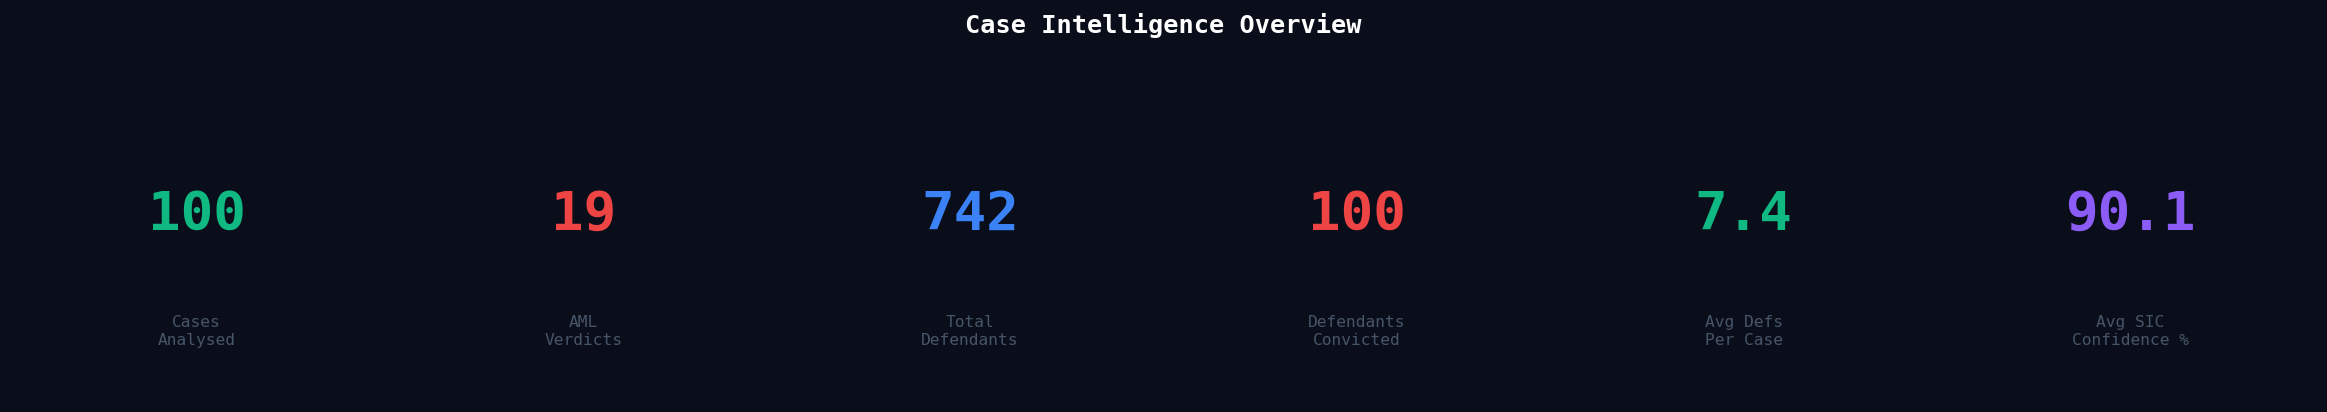

In [107]:
# ── CELL 3: Overview scorecard ─────────────────────────────────────────────────
total_cases        = len(cases)
total_defendants   = len(df_defs)
convicted          = len(df_defs[df_defs['verdict'] == 'Convicted'])
confirmed_verdicts = len(df_cases[df_cases['aml_status'] == 'Confirmed Verdict'])
avg_defs_per_case  = round(total_defendants / total_cases, 1) if total_cases else 0
avg_sic_conf       = round(df_sic['confidence'].mean(), 1) if len(df_sic) else 0

metrics = [
    ('Cases\nAnalysed',         total_cases,        ACCENT),
    ('AML\nVerdicts',           confirmed_verdicts,  '#ef4444'),
    ('Total\nDefendants',       total_defendants,    BLUE),
    ('Defendants\nConvicted',   convicted,           '#ef4444'),
    ('Avg Defs\nPer Case',      avg_defs_per_case,   GREEN),
    ('Avg SIC\nConfidence %',   avg_sic_conf,        '#8b5cf6'),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 3))
fig.patch.set_facecolor('#0a0e1a')
for ax, (label, value, color) in zip(axes, metrics):
    ax.set_facecolor('#111827')
    ax.axis('off')
    ax.text(0.5, 0.60, str(value), ha='center', va='center',
            fontsize=30, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=9, color='#475569', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2d45')
        spine.set_visible(True)

fig.suptitle('Case Intelligence Overview', fontsize=14, fontweight='bold',
             color='white', y=1.04)
plt.tight_layout()
plt.show()

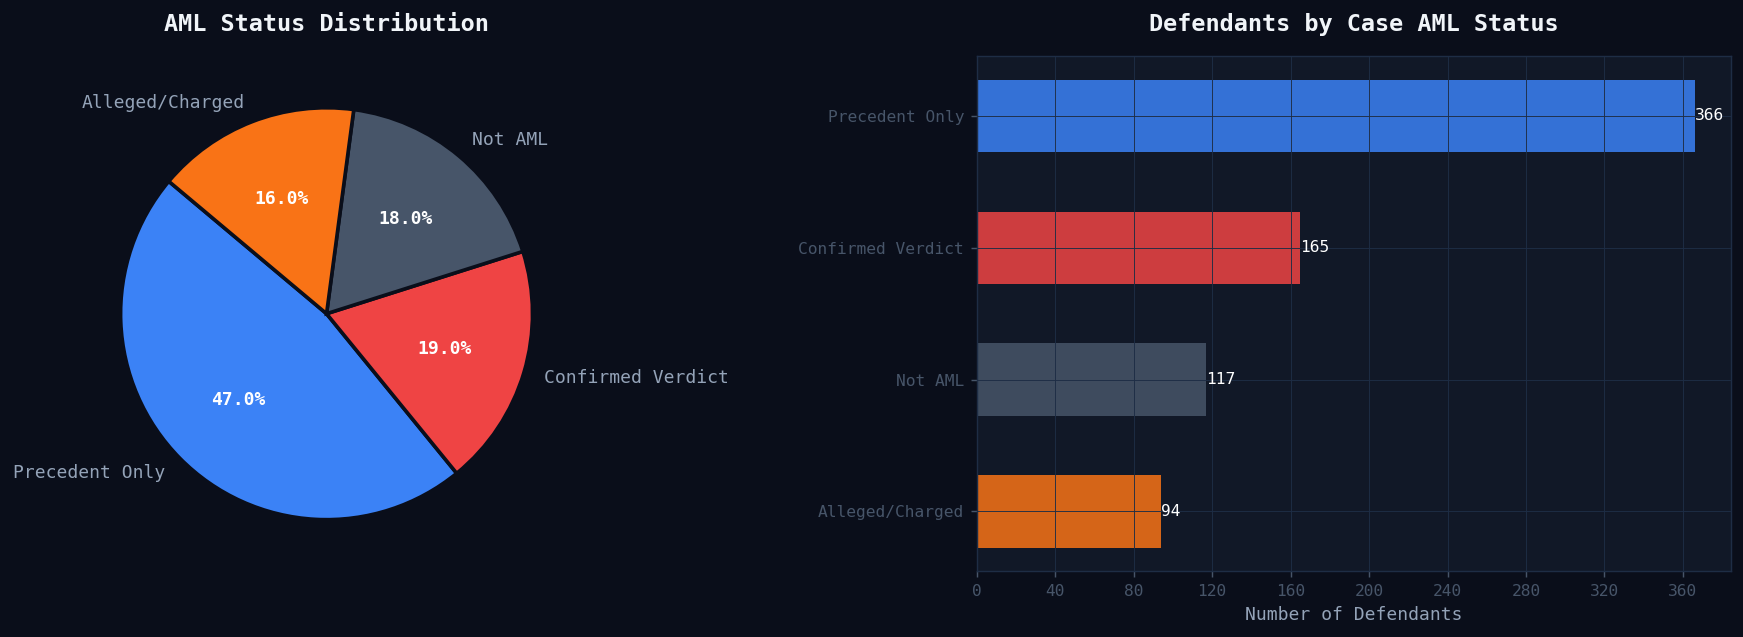

In [108]:
# ── CELL 4: AML status breakdown ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0e1a')

# Pie
status_counts = df_cases['aml_status'].value_counts()
pie_colors    = [AML_COLOURS.get(s, '#475569') for s in status_counts.index]
wedges, texts, autotexts = ax1.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'linewidth': 2, 'edgecolor': '#0a0e1a'},
    textprops={'color': '#94a3b8', 'fontsize': 10}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax1.set_title('AML Status Distribution')

# Bar — defendant count by AML status
def_by_status = df_defs.groupby('aml_status').size().sort_values(ascending=False)
bar_colors    = [AML_COLOURS.get(s, '#475569') for s in def_by_status.index]
bars = ax2.barh(def_by_status.index, def_by_status.values,
                color=bar_colors, alpha=0.85, height=0.55)
ax2.invert_yaxis()
ax2.set_title('Defendants by Case AML Status')
ax2.set_xlabel('Number of Defendants')
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for bar, val in zip(bars, def_by_status.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

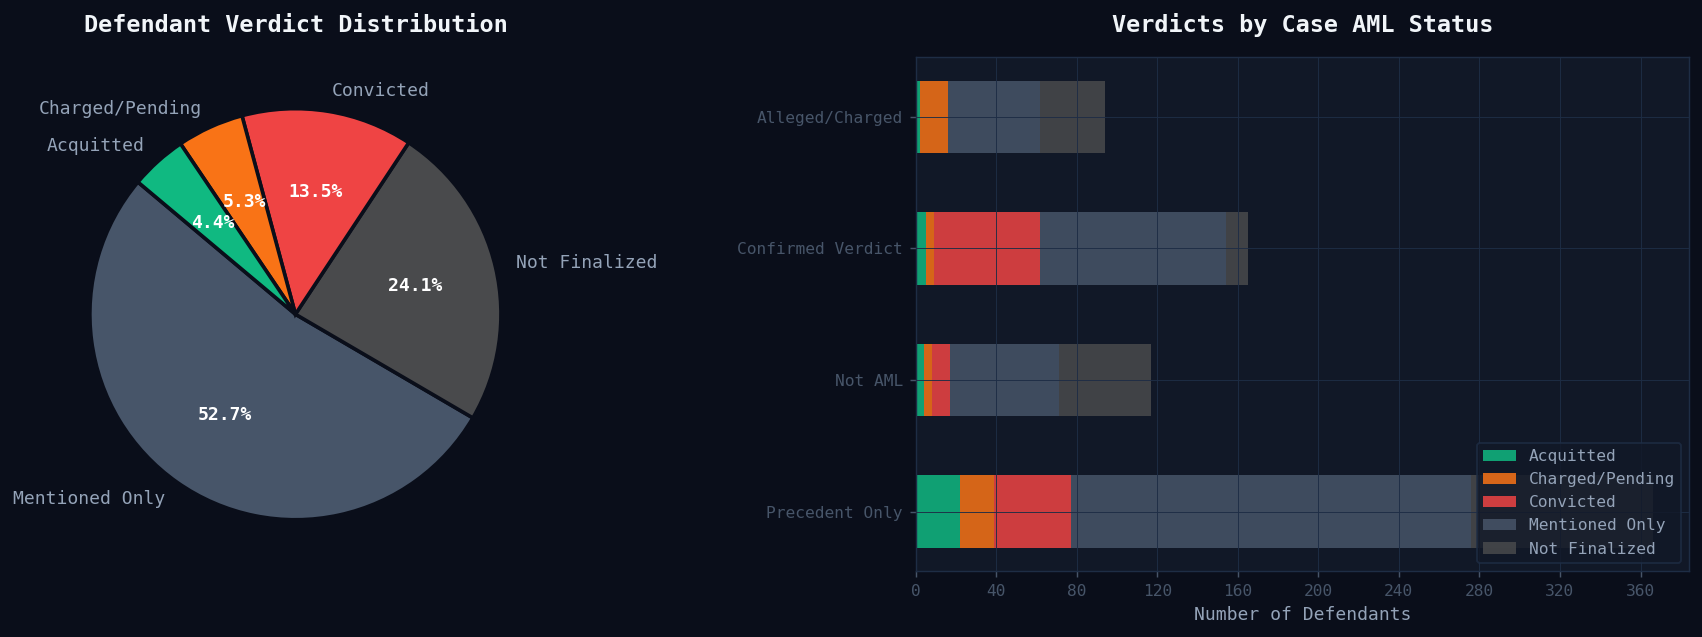

In [109]:
# ── CELL 5: Defendant verdicts ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0e1a')

# Verdict distribution pie
verdict_counts = df_defs['verdict'].value_counts()
v_colors       = [VERDICT_COLOURS.get(v, '#475569') for v in verdict_counts.index]
wedges, texts, autotexts = ax1.pie(
    verdict_counts.values,
    labels=verdict_counts.index,
    colors=v_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'linewidth': 2, 'edgecolor': '#0a0e1a'},
    textprops={'color': '#94a3b8', 'fontsize': 10}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax1.set_title('Defendant Verdict Distribution')

# Verdicts broken down by AML status — stacked bar
pivot = df_defs.groupby(['aml_status', 'verdict']).size().unstack(fill_value=0)
verdicts_in_data = pivot.columns.tolist()
v_stack_colors   = [VERDICT_COLOURS.get(v, '#475569') for v in verdicts_in_data]
bottom = None
for col, color in zip(verdicts_in_data, v_stack_colors):
    vals = pivot[col].values
    ax2.barh(pivot.index, vals, left=bottom, color=color,
             label=col, alpha=0.85, height=0.55)
    if bottom is None:
        bottom = vals.copy().astype(float)
    else:
        bottom += vals
ax2.invert_yaxis()
ax2.set_title('Verdicts by Case AML Status')
ax2.set_xlabel('Number of Defendants')
ax2.legend(loc='lower right')
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

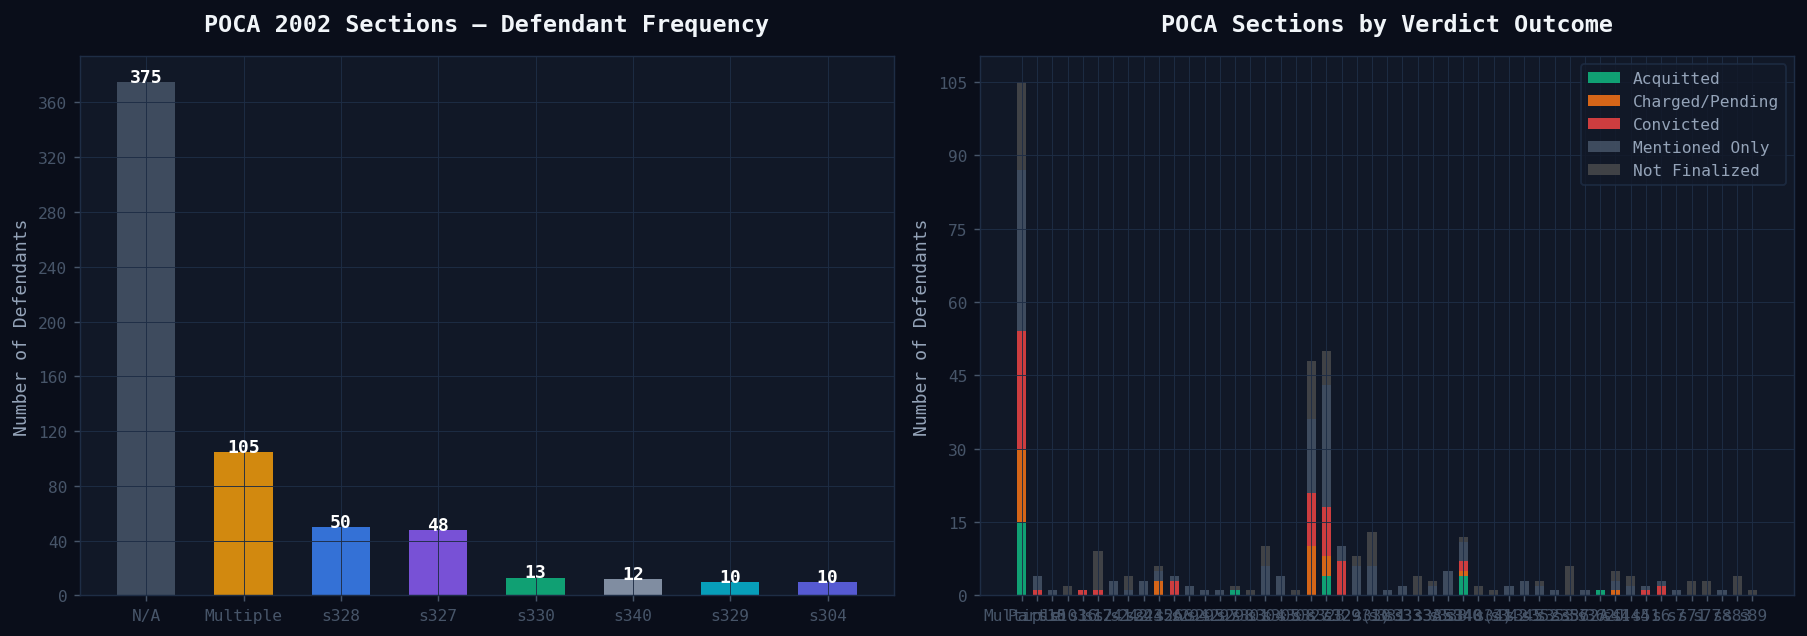

In [110]:
# ── CELL 6: POCA section analysis ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0e1a')

# POCA section frequency across defendants
poca_counts = df_defs['poca_section'].value_counts().head(8)
p_colors    = [POCA_COLOURS.get(p, ACCENT) for p in poca_counts.index]
bars = ax1.bar(poca_counts.index, poca_counts.values,
               color=p_colors, alpha=0.85, width=0.6)
ax1.set_title('POCA 2002 Sections — Defendant Frequency')
ax1.set_ylabel('Number of Defendants')
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
for bar, val in zip(bars, poca_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             str(val), ha='center', color='white', fontsize=10, fontweight='bold')

# POCA section by verdict
poca_verdict = df_defs[df_defs['poca_section'] != 'N/A'].groupby(
    ['poca_section', 'verdict']).size().unstack(fill_value=0)
verdicts_here = poca_verdict.columns.tolist()
v_colors2     = [VERDICT_COLOURS.get(v, '#475569') for v in verdicts_here]
bottom = None
for col, color in zip(verdicts_here, v_colors2):
    vals = poca_verdict[col].values
    ax2.bar(poca_verdict.index, vals, bottom=bottom,
            color=color, label=col, alpha=0.85, width=0.6)
    if bottom is None:
        bottom = vals.copy().astype(float)
    else:
        bottom += vals
ax2.set_title('POCA Sections by Verdict Outcome')
ax2.set_ylabel('Number of Defendants')
ax2.legend()
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

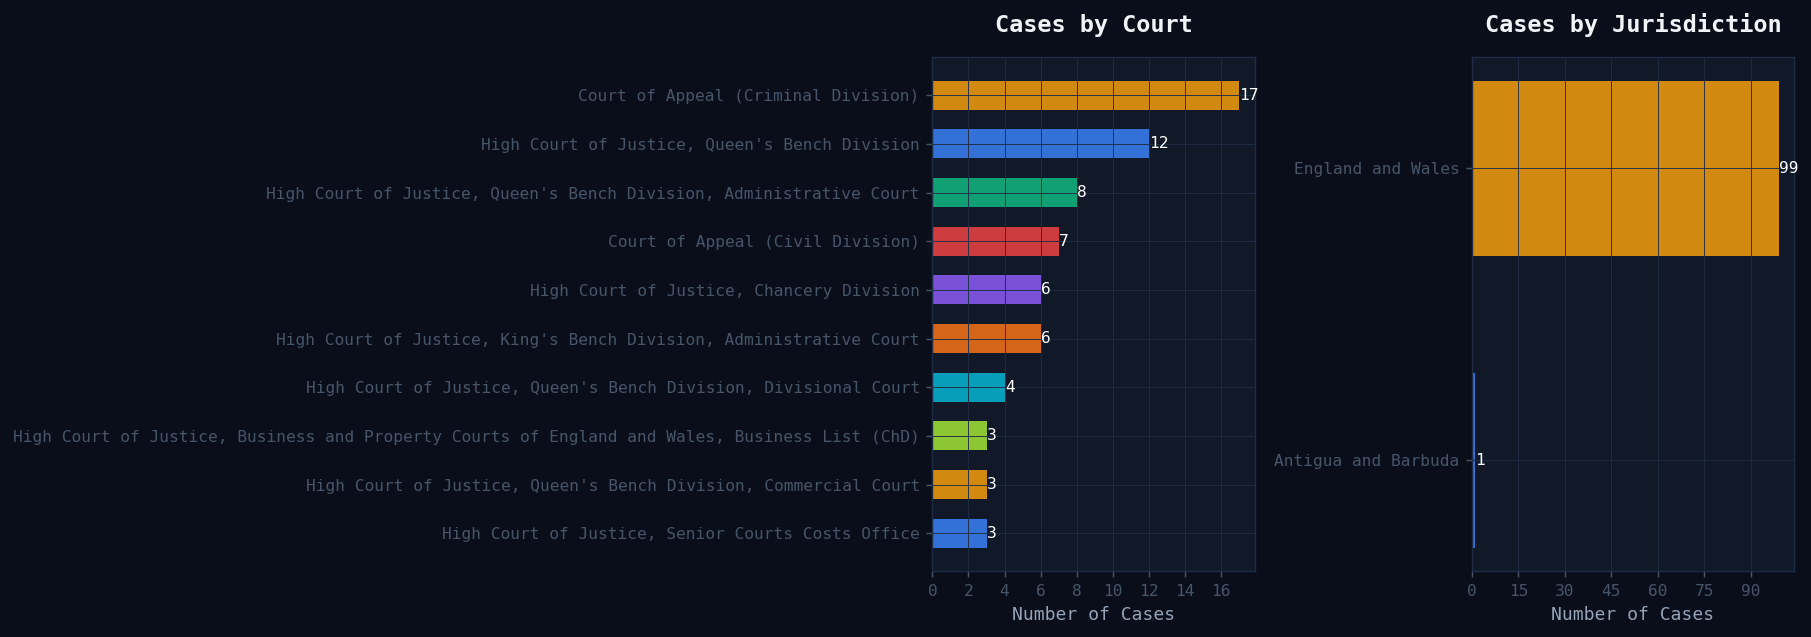

In [111]:
# ── CELL 7: Court and jurisdiction breakdown ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0e1a')

for ax, col, title in [
    (axes[0], 'court',        'Cases by Court'),
    (axes[1], 'jurisdiction', 'Cases by Jurisdiction'),
]:
    counts = df_cases[col].value_counts().dropna().head(10)
    if counts.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='#475569')
        ax.set_title(title)
        continue
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]
    bars = ax.barh(counts.index, counts.values, color=colors, alpha=0.85, height=0.6)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Number of Cases')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, counts.values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

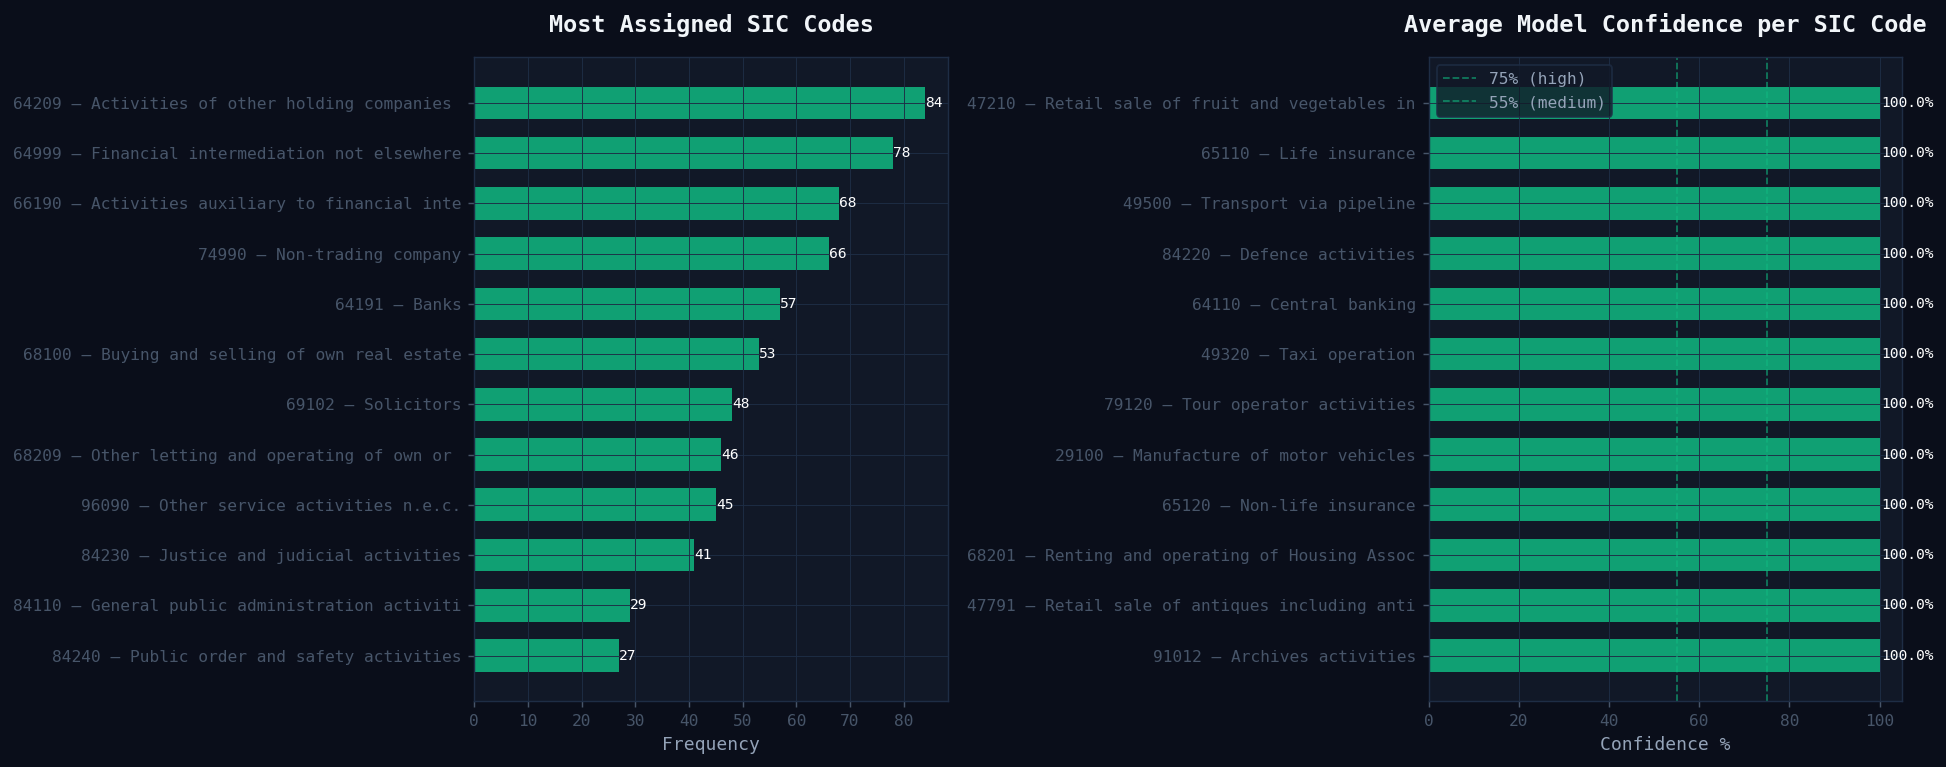

In [112]:
# ── CELL 8: SIC code frequency and confidence ──────────────────────────────────
if df_sic.empty:
    print('No SIC data available yet.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor('#0a0e1a')

    # Top SIC codes by frequency
    top_sic = (
        df_sic.groupby(['sic_code', 'sic_desc'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(12)
    )
    top_sic['label'] = top_sic['sic_code'] + ' — ' + top_sic['sic_desc'].str[:38]
    bars = ax1.barh(top_sic['label'], top_sic['count'],
                    color=ACCENT, alpha=0.85, height=0.65)
    ax1.invert_yaxis()
    ax1.set_title('Most Assigned SIC Codes')
    ax1.set_xlabel('Frequency')
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, top_sic['count']):
        ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', color='white', fontsize=8)

    # Average confidence per SIC code
    avg_conf = (
        df_sic.groupby(['sic_code', 'sic_desc'])['confidence']
        .mean()
        .reset_index()
        .sort_values('confidence', ascending=False)
        .head(12)
    )
    avg_conf['label'] = avg_conf['sic_code'] + ' — ' + avg_conf['sic_desc'].str[:38]
    conf_colors = [
        GREEN if c >= 75 else ACCENT if c >= 55 else '#475569'
        for c in avg_conf['confidence']
    ]
    bars2 = ax2.barh(avg_conf['label'], avg_conf['confidence'],
                     color=conf_colors, alpha=0.85, height=0.65)
    ax2.invert_yaxis()
    ax2.set_title('Average Model Confidence per SIC Code')
    ax2.set_xlabel('Confidence %')
    ax2.axvline(75, color=GREEN, linestyle='--', linewidth=1,
                alpha=0.6, label='75% (high)')
    ax2.axvline(55, color=ACCENT, linestyle='--', linewidth=1,
                alpha=0.6, label='55% (medium)')
    ax2.legend()
    for bar, val in zip(bars2, avg_conf['confidence']):
        ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', color='white', fontsize=8)

    plt.tight_layout()
    plt.show()

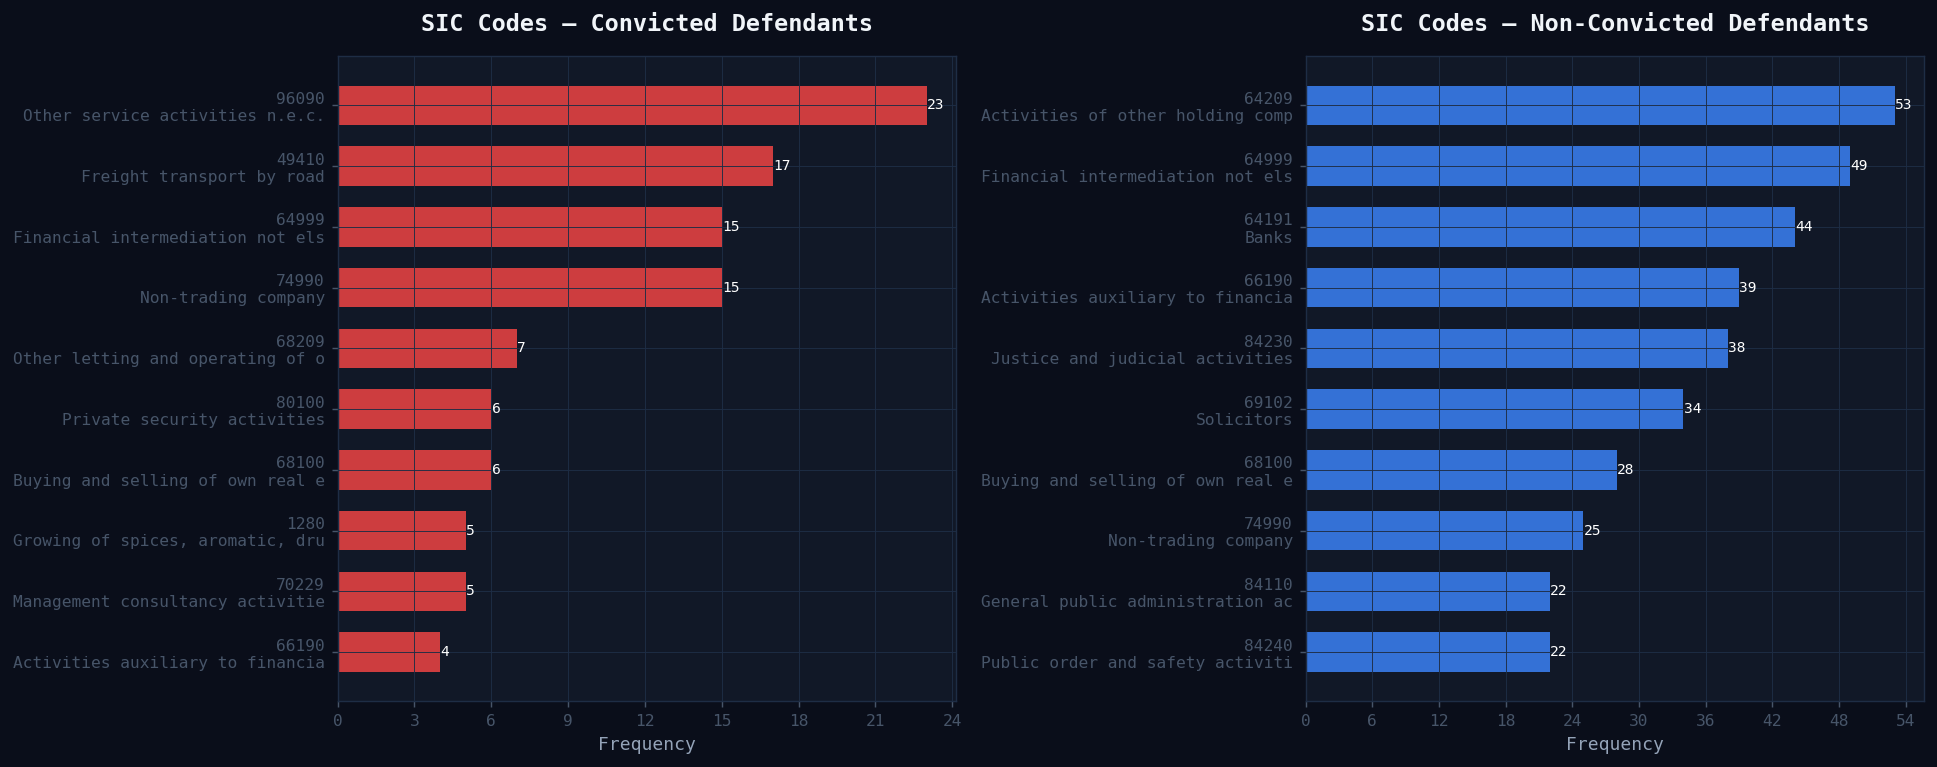

In [113]:
# ── CELL 9: SIC codes — convicted vs not convicted ─────────────────────────────
if df_sic.empty:
    print('No SIC data available yet.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.patch.set_facecolor('#0a0e1a')

    for ax, verdict_filter, title, color in [
        (ax1, 'Convicted',     'SIC Codes — Convicted Defendants',     '#ef4444'),
        (ax2, ['Acquitted', 'Charged/Pending', 'Mentioned Only'],
              'SIC Codes — Non-Convicted Defendants', BLUE),
    ]:
        if isinstance(verdict_filter, str):
            subset = df_sic[df_sic['verdict'] == verdict_filter]
        else:
            subset = df_sic[df_sic['verdict'].isin(verdict_filter)]

        if subset.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, color='#475569')
            ax.set_title(title)
            continue

        counts = (
            subset.groupby(['sic_code', 'sic_desc'])
            .size()
            .reset_index(name='count')
            .sort_values('count', ascending=False)
            .head(10)
        )
        counts['label'] = counts['sic_code'] + '\n' + counts['sic_desc'].str[:32]
        bars = ax.barh(counts['label'], counts['count'],
                       color=color, alpha=0.85, height=0.65)
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel('Frequency')
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        for bar, val in zip(bars, counts['count']):
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', color='white', fontsize=8)

    plt.tight_layout()
    plt.show()

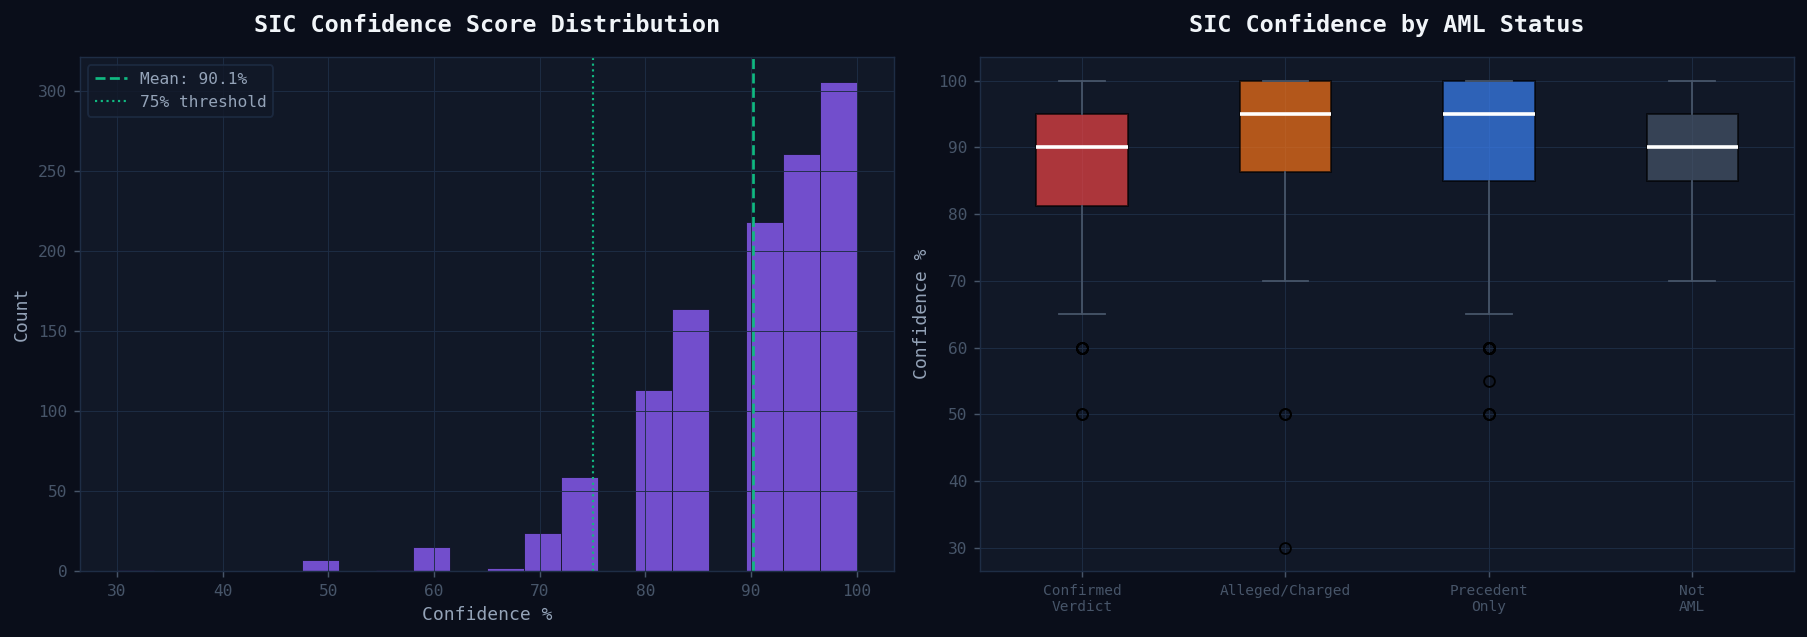

In [114]:
# ── CELL 10: Confidence distribution ──────────────────────────────────────────
if df_sic.empty:
    print('No SIC data available yet.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0a0e1a')

    ax1.hist(df_sic['confidence'].dropna(), bins=20,
             color='#8b5cf6', alpha=0.8, edgecolor='#0a0e1a', linewidth=0.5)
    ax1.axvline(df_sic['confidence'].mean(), color=ACCENT, linestyle='--',
                linewidth=1.5, label=f"Mean: {df_sic['confidence'].mean():.1f}%")
    ax1.axvline(75, color=GREEN, linestyle=':', linewidth=1.2, label='75% threshold')
    ax1.set_title('SIC Confidence Score Distribution')
    ax1.set_xlabel('Confidence %')
    ax1.set_ylabel('Count')
    ax1.legend()

    # Box plot per AML status
    aml_order  = ['Confirmed Verdict', 'Alleged/Charged', 'Precedent Only', 'Not AML']
    box_data   = [df_sic[df_sic['aml_status'] == s]['confidence'].dropna().tolist()
                  for s in aml_order]
    box_data   = [(d if d else [0]) for d in box_data]
    bp = ax2.boxplot(box_data, patch_artist=True, notch=False,
                     medianprops={'color': 'white', 'linewidth': 2})
    for patch, status in zip(bp['boxes'], aml_order):
        patch.set_facecolor(AML_COLOURS.get(status, '#475569'))
        patch.set_alpha(0.7)
    for element in ['whiskers', 'caps', 'fliers']:
        for item in bp[element]:
            item.set_color('#475569')
    ax2.set_xticks(range(1, len(aml_order)+1))
    ax2.set_xticklabels([s.replace(' ', '\n') for s in aml_order], fontsize=8)
    ax2.set_title('SIC Confidence by AML Status')
    ax2.set_ylabel('Confidence %')

    plt.tight_layout()
    plt.show()

In [115]:
# ── CELL 11: Key findings across all cases ─────────────────────────────────────
all_findings = []
for c in cases:
    for finding in c.get('key_findings', []):
        all_findings.append({'case': c.get('case_reference', ''), 'finding': finding})

if all_findings:
    df_findings = pd.DataFrame(all_findings)
    pd.set_option('display.max_colwidth', 120)
    print(f'Total key findings across {len(cases)} case(s):\n')
    print(df_findings.to_string(index=False))
else:
    print('No key findings extracted yet.')

Total key findings across 100 case(s):

                     case                                                                                                                                                                                                                                                                                                                                                                                                                                                                        finding
    [2018] EWCA Crim 1170                                                                                                   Money laundering (POCA 2002) is a separate and distinct species of criminality from the underlying predicate offences (such as drug supply), and sentences for money laundering should generally run consecutively to rather than concurrently with the predicate offence sentences, even when the laundered funds represent the direct profits of those pr

In [116]:
# ── CELL 12: Case summary table ────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 100)

summary = df_cases[[
    'case_reference', 'court', 'case_date',
    'aml_status', 'case_summary', 'poca_sections' 
]].copy()

summary.columns = [
    'Case Reference', 'Court', 'Date',
    'AML Status', 'Summary', 'POCA Sections'
]

print('CASE SUMMARY\n' + '─' * 80)
print(summary.to_string(index=False))

CASE SUMMARY
────────────────────────────────────────────────────────────────────────────────
           Case Reference                                                                                                                          Court       Date        AML Status                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [117]:
# ── CELL 13: Defendant detail table ───────────────────────────────────────────
detail = df_defs[[
    'case_reference', 'name', 'role', 'verdict', 'poca_section'
]].copy()

detail.columns = ['Case', 'Defendant', 'Role', 'Verdict', 'POCA']

# Colour verdict column text in output
print('DEFENDANT DETAIL\n' + '─' * 80)
print(detail.to_string(index=False))

DEFENDANT DETAIL
────────────────────────────────────────────────────────────────────────────────
                     Case                                                               Defendant                           Role         Verdict     POCA
    [2018] EWCA Crim 1170                                                  Nicholas Richard Adair                      Defendant       Convicted Multiple
    [2018] EWCA Crim 1170                                                               Casey Nay                      Defendant Charged/Pending     s328
    [2018] EWCA Crim 1170                                                      Christine Raisbeck                      Defendant Charged/Pending     s328
    [2018] EWCA Crim 1170                                                                 Gentles                      Defendant       Convicted      N/A
     [2008] EWCA Civ 1007                                                     Mohammed Iqbal Meer                      Defendant    

In [118]:
# ── CELL 14: AML reasoning review ─────────────────────────────────────────────
# Useful for manually reviewing model reasoning quality
print('AML STATUS REASONING REVIEW\n' + '═' * 80)
for c in cases:
    print(f"\nCase   : {c.get('case_reference')}")
    print(f"Status : {c.get('aml_status')}")
    print(f"Reason : {c.get('aml_status_reasoning', 'N/A')}")
    print('─' * 80)

AML STATUS REASONING REVIEW
════════════════════════════════════════════════════════════════════════════════

Case   : [2018] EWCA Crim 1170
Status : Confirmed Verdict
Reason : The judgment details the appeal of sentences passed on Nicholas Richard Adair, who pleaded guilty to three counts of money laundering under POCA 2002 (specifically entering into or becoming involved in a money laundering arrangement contrary to s328(1), converting criminal property contrary to s327(1)(c), and possessing criminal property contrary to s329(1)). The Court of Appeal confirmed these convictions, held that money laundering is a separate and distinct species of criminality, and increased the offender's overall sentence by directing that the money laundering count (s328) run consecutively to his drug supply and violence offences.
────────────────────────────────────────────────────────────────────────────────

Case   : [2008] EWCA Civ 1007
Status : Precedent Only
Reason : This is a civil asset recovery 

In [119]:
# ── CELL 15: Defendant verdict reasoning review ────────────────────────────────
# Useful for auditing the model's defendant-level reasoning
print('DEFENDANT VERDICT REASONING\n' + '═' * 80)
for c in cases:
    print(f"\n{c.get('case_reference')} [{c.get('aml_status')}]")
    for d in c.get('defendants', []):
        print(f"  Defendant : {d.get('name')}")
        print(f"  Verdict   : {d.get('verdict')}")
        print(f"  POCA      : {d.get('poca_section')}")
        print(f"  Reasoning : {d.get('verdict_reasoning', 'N/A')}")
        print()

DEFENDANT VERDICT REASONING
════════════════════════════════════════════════════════════════════════════════

[2018] EWCA Crim 1170 [Confirmed Verdict]
  Defendant : Nicholas Richard Adair
  Verdict   : Convicted
  POCA      : Multiple
  Reasoning : Adair pleaded guilty to three money laundering counts under POCA (s327, s328, s329), drug supply, and GBH wounding. The Court of Appeal increased his sentence to 14 years by making the money laundering (s328) sentence run consecutively (2 years) instead of concurrently, finding the previous 12-year concurrent sentence unduly lenient.

  Defendant : Casey Nay
  Verdict   : Charged/Pending
  POCA      : s328
  Reasoning : Arrested on suspicion of money laundering on April 28, 2016, and subsequently charged under POCA 2002 for her role in depositing and layering Adair's drug cash through her bank account. Her final verdict is not finalized in this specific appellate judgment, which is restricted to Adair's sentence appeal.

  Defendant : Chris

In [120]:
# ── CELL 16: Export to Excel ───────────────────────────────────────────────────
# Exports all analytical dataframes to a structured .xlsx workbook.
# Edit output_path to change the save location.

from IPython.display import display, HTML
output_path = 'aml_insights.xlsx'

# ── Helper ─────────────────────────────────────────────────────────────────────
def pipe_join(val):
    """Flatten a list field to a pipe-joined string for Excel readability."""
    if isinstance(val, list):
        return ' | '.join(str(v) for v in val if v)
    return val or ''

# ── Sheet 1: Cases ─────────────────────────────────────────────────────────────
# Full case-level data including fields dropped from the original export
# (judge, parties, docket_number) and key_findings pipe-joined inline.
cases_export = []
for c in cases:
    enriched_poca = c.get('poca_sections_enriched', {})
    poca_titles   = [info.get('title', '') for info in enriched_poca.values() if info.get('title')]
    poca_low_conf = [s for s, info in enriched_poca.items() if info.get('confidence', '').lower() == 'low']
    poca_conf_rsn = '; '.join(
        f"{s}: {info.get('confidence_reasoning', 'no reasoning given')}"
        for s, info in enriched_poca.items() if info.get('confidence', '').lower() == 'low'
    )
    cases_export.append({
        'Case Reference':           c.get('case_reference'),
        'Case Name':                c.get('case_name'),
        'Court':                    c.get('court'),
        'Jurisdiction':             c.get('jurisdiction'),
        'Date':                     c.get('case_date'),
        'Judge':                    c.get('judge'),
        'Docket Number':            c.get('docket_number'),
        'Parties':                  pipe_join(c.get('parties', [])),
        'AML Status':               c.get('aml_status'),
        'AML Status Reasoning':     c.get('aml_status_reasoning'),
        'POCA Sections':            ', '.join(c.get('poca_sections', [])),
        'POCA Titles':              ', '.join(poca_titles),
        'POCA Analysis':            c.get('poca_analysis'),
        'POCA Low Confidence':      ', '.join(poca_low_conf),
        'POCA Confidence Reasoning': poca_conf_rsn,
        'POCA Fetch Failed':        pipe_join(c.get('poca_fetch_failed_sections', [])),
        'Precedent Value':          c.get('precedent_value'),
        'Key Findings':             pipe_join(c.get('key_findings', [])),
        'Case Summary':             c.get('case_summary'),
        'Defendant Count':          c.get('defendant_count', 0),
        'Source File':              c.get('source_file'),
    })
df_cases_export = pd.DataFrame(cases_export)

# ── Sheet 2: Defendants ────────────────────────────────────────────────────────
# Full defendant-level data with key_facts pipe-joined and top SIC code
# added so the sheet is self-contained without needing to join df_sic.
defs_export = []
for c in cases:
    for d in c.get('defendants', []):
        sics     = d.get('sic_codes', [])
        top_sic  = sics[0].get('code', '')        if sics else ''
        top_desc = sics[0].get('description', '')  if sics else ''
        raw_conf = sics[0].get('confidence', 0) if sics else 0
        top_conf = int(str(raw_conf).replace('%', '')) if raw_conf else 0
        defs_export.append({
            'Case Reference':          c.get('case_reference'),
            'Case Name':               c.get('case_name'),
            'AML Status':              c.get('aml_status'),
            'Defendant Name':          d.get('name'),
            'Role':                    d.get('role'),
            'Verdict':                 d.get('verdict'),
            'Verdict Reasoning':       d.get('verdict_reasoning'),
            'POCA Section':            d.get('poca_section'),
            'POCA Section Reasoning':  d.get('poca_section_reasoning'),
            'Key Facts':               pipe_join(d.get('key_facts', [])),
            'SIC Count':               len(sics),
            'Top SIC Code':            top_sic,
            'Top SIC Description':     top_desc,
            'Top SIC Confidence':      top_conf,
            'SIC Overall Reasoning':   d.get('sic_overall_reasoning'),
        })
df_defs_export = pd.DataFrame(defs_export)

# ── Sheet 3: SIC Codes ─────────────────────────────────────────────────────────
# Consistent naming (defendant_name not defendant) to match df_defs_export,
# case_name joined in so the sheet is self-contained.
sic_lookup = {c.get('case_reference'): c.get('case_name') for c in cases}
sic_export = []
for c in cases:
    for d in c.get('defendants', []):
        for sic in d.get('sic_codes', []):
            raw_conf = sic.get('confidence', 0)
            conf_val = int(str(raw_conf).replace('%', '')) if raw_conf else 0
            sic_export.append({
                'Case Reference':   c.get('case_reference'),
                'Case Name':        c.get('case_name'),
                'AML Status':       c.get('aml_status'),
                'Defendant Name':   d.get('name'),
                'Verdict':          d.get('verdict'),
                'POCA Section':     d.get('poca_section'),
                'SIC Code':         sic.get('code'),
                'SIC Description':  sic.get('description'),
                'Confidence':       conf_val,
                'Reasoning':        sic.get('reasoning'),
            })
df_sic_export = pd.DataFrame(sic_export)

# ── Sheet 4: Full Defendant View ───────────────────────────────────────────────
# Merged case + defendant data in one flat sheet — useful for pivot tables
# and cross-case filtering without needing to join in Excel.
df_full_def_view = df_defs_export.copy()

# ── Sheet 5: Key Findings ──────────────────────────────────────────────────────
# One row per finding per case — useful for thematic analysis across cases.
findings_export = []
for c in cases:
    for i, finding in enumerate(c.get('key_findings', []), start=1):
        findings_export.append({
            'Case Reference': c.get('case_reference'),
            'Case Name':      c.get('case_name'),
            'Court':          c.get('court'),
            'AML Status':     c.get('aml_status'),
            'Finding #':      i,
            'Finding':        finding,
        })
df_findings_export = pd.DataFrame(findings_export)

# ── Sheet 6: POCA Audit ────────────────────────────────────────────────────────
# One row per POCA section per case — enrichment fields, confidence flags,
# and fetch-failure markers in one place for legal accuracy review.
poca_audit_rows = []
for c in cases:
    enriched = c.get('poca_sections_enriched', {})
    failed   = c.get('poca_fetch_failed_sections') or []
    for section in c.get('poca_sections', []):
        info = enriched.get(section, {})
        poca_audit_rows.append({
            'Case Reference':        c.get('case_reference'),
            'Case Name':             c.get('case_name'),
            'Court':                 c.get('court'),
            'Date':                  c.get('case_date'),
            'AML Status':            c.get('aml_status'),
            'POCA Section':          section,
            'Title':                 info.get('title', ''),
            'Part / Chapter':        info.get('part_chapter', ''),
            'Full Description':      info.get('full', ''),
            'Elements':              pipe_join(info.get('elements', [])),
            'Notes':                 info.get('notes', ''),
            'Confidence':            info.get('confidence', ''),
            'Confidence Reasoning':  info.get('confidence_reasoning', ''),
            'Fetch Failed':          'Yes' if section in failed else '',
        })
df_poca_audit = pd.DataFrame(poca_audit_rows)

# ── Write workbook ─────────────────────────────────────────────────────────────
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_cases_export.to_excel(writer,    sheet_name='Cases',              index=False)
    df_defs_export.to_excel(writer,     sheet_name='Defendants',         index=False)
    df_sic_export.to_excel(writer,      sheet_name='SIC Codes',          index=False)
    df_full_def_view.to_excel(writer,   sheet_name='Full Defendant View', index=False)
    if findings_export:
        df_findings_export.to_excel(writer, sheet_name='Key Findings',   index=False)
    if poca_audit_rows:
        df_poca_audit.to_excel(writer,      sheet_name='POCA Audit',     index=False)

# ── Summary ────────────────────────────────────────────────────────────────────
summary_html = f"""
<div style="background:#0a0e1a;border:1px solid #1e2d45;border-radius:8px;
            padding:16px 20px;font-family:ui-monospace,monospace;margin-top:8px;">
    <div style="color:#e2e8f0;font-size:13px;font-weight:600;margin-bottom:10px;">
        ✓ Exported to <span style="color:#3b82f6;">{output_path}</span>
    </div>
    <table style="width:100%;border-collapse:collapse;font-size:11px;">
        <tr>
            <th style="text-align:left;color:#64748b;padding:3px 12px 3px 0;
                       text-transform:uppercase;letter-spacing:0.06em;">Sheet</th>
            <th style="text-align:right;color:#64748b;padding:3px 0;
                       text-transform:uppercase;letter-spacing:0.06em;">Rows</th>
        </tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">Cases</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_cases_export)}</td></tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">Defendants</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_defs_export)}</td></tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">SIC Codes</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_sic_export)}</td></tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">Full Defendant View</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_full_def_view)}</td></tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">Key Findings</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_findings_export) if findings_export else 0}</td></tr>
        <tr><td style="color:#e2e8f0;padding:3px 12px 3px 0;">POCA Audit</td>
            <td style="color:#3b82f6;text-align:right;">{len(df_poca_audit) if poca_audit_rows else 0}</td></tr>
    </table>
</div>
"""
display(HTML(summary_html))


Sheet,Rows
Cases,100
Defendants,742
SIC Codes,1171
Full Defendant View,742
Key Findings,615
POCA Audit,358
